In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings

warnings.filterwarnings("ignore")


In [3]:
data = pd.read_csv("S06-hw-dataset-04.csv")
data.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
0,1,-1.250210,1.423474,-0.225004,-4.023138,-0.832729,-0.550874,1.772090,2.761690,-0.698750,...,10.938269,0.501178,1.600001,0.314212,1.209735,1.355697,-5.338924,1.153944,-0.153934,0
1,2,0.074328,0.376429,0.212831,-0.502074,2.017405,0.625496,1.943785,1.242030,-0.524090,...,7.775262,-4.550195,6.272586,-0.932162,-0.228543,1.735220,-3.827828,0.292165,0.273720,0
2,3,0.638481,0.060968,0.746760,2.479653,-0.292858,-0.078139,-2.918423,-0.013186,1.009135,...,-4.448447,-9.593179,-3.093519,0.029321,0.605511,0.829103,-0.085985,2.891408,0.766221,0
3,4,1.712916,-1.350969,-0.256473,1.622074,-0.445141,0.911932,-3.440345,1.505192,-1.104348,...,-1.619072,-3.237479,-5.474038,-1.582475,0.198137,3.823409,0.880395,1.148610,0.136732,0
4,5,0.905676,-0.206545,-0.068806,4.086026,-1.010045,-0.772644,-4.207688,2.506104,1.589143,...,-2.396844,-10.540129,-5.532811,-1.231203,0.000119,4.298572,-1.558235,0.924673,0.111668,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 62 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      25000 non-null  int64  
 1   f01     25000 non-null  float64
 2   f02     25000 non-null  float64
 3   f03     25000 non-null  float64
 4   f04     25000 non-null  float64
 5   f05     25000 non-null  float64
 6   f06     25000 non-null  float64
 7   f07     25000 non-null  float64
 8   f08     25000 non-null  float64
 9   f09     25000 non-null  float64
 10  f10     25000 non-null  float64
 11  f11     25000 non-null  float64
 12  f12     25000 non-null  float64
 13  f13     25000 non-null  float64
 14  f14     25000 non-null  float64
 15  f15     25000 non-null  float64
 16  f16     25000 non-null  float64
 17  f17     25000 non-null  float64
 18  f18     25000 non-null  float64
 19  f19     25000 non-null  float64
 20  f20     25000 non-null  float64
 21  f21     25000 non-null  float64
 22

In [4]:
data.describe()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,12500.500000,-0.000386,-0.004872,0.003202,0.335329,-0.000563,-0.010118,0.001182,0.957385,-0.004658,...,-0.166251,-3.387506,1.749793,-0.013017,-0.001383,0.893365,-0.909479,0.000570,-0.000754,0.04920
std,7217.022701,1.001623,0.995606,1.004367,3.207537,0.993965,1.002172,2.432162,1.830223,1.013470,...,4.234741,4.331576,5.318660,1.001594,0.996409,2.445185,1.962618,0.994320,0.997167,0.21629
min,1.000000,-4.370993,-4.087073,-4.103875,-13.249937,-4.118778,-3.895974,-8.883224,-8.132548,-4.068933,...,-20.021141,-18.332290,-20.336666,-4.349216,-4.119472,-9.508509,-7.919287,-4.038312,-3.812255,0.00000
25%,6250.750000,-0.680165,-0.675100,-0.675426,-1.750048,-0.669764,-0.674374,-1.647977,-0.217260,-0.688278,...,-2.897904,-6.278403,-1.775889,-0.689962,-0.676191,-0.735473,-2.226959,-0.666367,-0.665861,0.00000
50%,12500.500000,0.001859,-0.000247,0.013272,0.403483,-0.001309,-0.005994,-0.011349,0.963009,0.000414,...,-0.396946,-3.462072,1.931851,-0.020933,-0.004193,0.888535,-0.923354,0.004381,0.002420,0.00000
75%,18750.250000,0.679702,0.659523,0.683437,2.486453,0.672299,0.652629,1.658680,2.167758,0.681040,...,2.344956,-0.578540,5.473886,0.661300,0.673722,2.516790,0.395648,0.666474,0.665918,0.00000
max,25000.000000,4.208888,3.984564,3.793442,15.288250,4.020733,4.279607,9.538525,9.321099,4.261349,...,20.717964,18.818764,20.688069,4.338337,3.902131,11.880651,6.778980,3.834922,4.012639,1.00000


In [7]:
print(data['target'].value_counts(normalize=True))

target
0    0.9508
1    0.0492
Name: proportion, dtype: float64


В данных гигантский дисбаланс, поэтому в первую очередь будем обращать внимание на 1 класс, так как предсказание этого класса будет давать во многие метрики незначительный вклад, однако критически важно для смысла нашеих моделей.

In [4]:
X = data.drop(columns=["id", "target"])
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

 - random_state=42 гарантирует, что при каждом запуске разбиение будет одинаковым. Это важно для воспроизводимости результатов и корректного сравнения моделей.
 - stratify=y обеспечивает, что пропорции классов в train и test будут такими же, как в исходных данных. Это критически важно при работе с несбалансированными данными, чтобы в тестовой выборке были представлены оба класса.


In [6]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      4754
           1       0.00      0.00      0.00       246

    accuracy                           0.95      5000
   macro avg       0.48      0.50      0.49      5000
weighted avg       0.90      0.95      0.93      5000



Модель всегда предсказывает самый частый класс (0 в нашем случае). Это нижняя граница качества - любая осмысленная модель должна быть лучше.

In [5]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=4000, class_weight="balanced"))
])

lr_pipeline.fit(X_train, y_train)
y_pred = lr_pipeline.predict(X_test)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred), "\nRoc-auc score:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.99      0.78      0.87      4754
           1       0.15      0.78      0.25       246

    accuracy                           0.78      5000
   macro avg       0.57      0.78      0.56      5000
weighted avg       0.94      0.78      0.84      5000
 
Roc-auc score: 0.8355052313669961


Линейная модель с балансировкой классов. Показывает, можно ли решить задачу с помощью линейных зависимостей. Ну и является минимальным порогом по качеству.

In [ ]:
Для DecisionTreeClassifier не обнаружен контроль сложности 
(max_depth/min_samples_leaf/min_samples_split/max_leaf_nodes/min_impurity_decrease/ccp_alpha); 
Сигналы: (Сигнал) Обнаружено использование X_test/y_test внутри цикла — возможен некорректный выбор модели по test

In [5]:
param_grid_tree = {
    'max_depth': [1, 3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10, 20],
}

model = DecisionTreeClassifier(random_state=42, class_weight="balanced")
tree = GridSearchCV(
    model,
    param_grid_tree,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1
)

tree.fit(X_train, y_train)
print(f"Лучшие параметры: {tree.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {tree.best_score_:.4f}")

Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 20}
Лучший ROC-AUC на кросс-валидации: 0.8106


In [9]:
best_tree = tree.best_estimator_
y_pred = best_tree.predict(X_test)
y_proba = best_tree.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred), "\nRoc-auc score:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.98      0.89      0.93      4754
           1       0.25      0.74      0.37       246

    accuracy                           0.88      5000
   macro avg       0.62      0.81      0.65      5000
weighted avg       0.95      0.88      0.90      5000
 
Roc-auc score: 0.8328660332249095


Как мы видим результат улучшился, он точно лучше наших бейзлайн моделей и уже может верно предсказать около 40 процентов меньшего класса.

In [100]:
param_grid_forest = {
    'n_estimators': [50, 100, 200],
    'max_depth': [1, 5, 10, None],
    'max_features': ['sqrt', 'log2', 0.5],
    'min_samples_leaf': [1, 5, 10]
}

model = RandomForestClassifier(random_state=42, class_weight="balanced")
forest = GridSearchCV(
    model,
    param_grid_forest,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

forest.fit(X_train, y_train)
print(f"Лучшие параметры: {forest.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {forest.best_score_:.4f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Лучший ROC-AUC на кросс-валидации: 0.8947


In [101]:
best_forest = forest.best_estimator_
y_pred = best_forest.predict(X_test)
y_proba = best_forest.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred), "\nRoc-auc score:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4754
           1       0.99      0.55      0.70       246

    accuracy                           0.98      5000
   macro avg       0.98      0.77      0.85      5000
weighted avg       0.98      0.98      0.97      5000
 
Roc-auc score: 0.8992034093668662


Собственно результат заметно улучшился, и модель корректно предсказывает 70% меньшего класса и почти весь 0 класс. 

In [59]:
param_grid_gb = {
    'max_iter': [50, 100, 200, 500, 1000, 2000, 4000],
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'max_depth': [1, 3, 5, 10, 20, 50, None]
}

model = HistGradientBoostingClassifier(random_state=42, class_weight="balanced")
gb = GridSearchCV(
    model,
    param_grid_gb,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

gb.fit(X_train, y_train)
print(f"Лучшие параметры: {gb.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {gb.best_score_:.4f}")

Fitting 3 folds for each of 196 candidates, totalling 588 fits
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 10, 'max_iter': 500}
Лучший ROC-AUC на кросс-валидации: 0.8922


In [60]:
best_gb = gb.best_estimator_
y_pred = best_gb.predict(X_test)
y_proba = best_gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred), "\nRoc-auc score:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      4754
           1       0.49      0.78      0.60       246

    accuracy                           0.95      5000
   macro avg       0.74      0.87      0.79      5000
weighted avg       0.96      0.95      0.95      5000
 
Roc-auc score: 0.8981841564313833


In [68]:
param_grid_ada = {
    'n_estimators': [50, 100, 200, 500, 1000, 2000],
    'learning_rate': [0.001, 0.01, 0.05, 0.1]
}

model = AdaBoostClassifier(random_state=42)
ada = GridSearchCV(
    model,
    param_grid_ada,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)
ada.fit(X_train, y_train)
print(f"Лучшие параметры: {ada.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {ada.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Лучшие параметры: {'learning_rate': 0.1, 'n_estimators': 2000}
Лучший ROC-AUC на кросс-валидации: 0.8709


In [69]:
best_ada = ada.best_estimator_
y_pred = best_ada.predict(X_test)
y_proba = best_ada.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred), "\nRoc-auc score:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4754
           1       0.92      0.23      0.36       246

    accuracy                           0.96      5000
   macro avg       0.94      0.61      0.67      5000
weighted avg       0.96      0.96      0.95      5000
 
Roc-auc score: 0.8742522343187252


Бустинг показал результат хуже, чем рандомный лес, но, все же лучше чем бэйзлайн модели. Это возможно из-за неточной настройки гиперпараметров, а также огромного дисбаланса, так adaboost как оказалось даже не имеет никаких инструментов для акцентирования внимания на этой проблеме, поэтому показал весьма посредственный результат.

In [117]:
lr_for_staking = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(random_state=42, max_iter=4000, class_weight="balanced"))
])

stacking = StackingClassifier(
    estimators=[
        ("LogisticRegression", lr_pipeline),
        ("DecisionTreeClassifier", best_tree),
        ("RandomForestClassifier", best_forest),
        ("AdaBoostClassifier", best_ada),
        ("HistGradientBoostingClassifier", best_gb)
    ],
    final_estimator=lr_for_staking,
    cv=StratifiedKFold(n_splits=5, random_state=5, shuffle=True),
    n_jobs=-1
)

stacking.fit(X_train, y_train)
y_pred = stacking.predict(X_test)
y_proba = stacking.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred), "\nRoc-auc score:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      4754
           1       0.44      0.80      0.57       246

    accuracy                           0.94      5000
   macro avg       0.72      0.87      0.77      5000
weighted avg       0.96      0.94      0.95      5000
 
Roc-auc score: 0.9009759859904025


Стекинг показал хороший результат по roc-auc, но вот по угаданным классам немного просел.

По итогу, наиболее сильной моделью оказался стекинг, хотя случайный лес немного меньше имеет roc-auc, классы он все же предсказывает лучше. Однако будем ориентироваться на метрику, поэтому посчитаем permutation importance на стекинге:

In [120]:
result = permutation_importance(
    stacking,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)


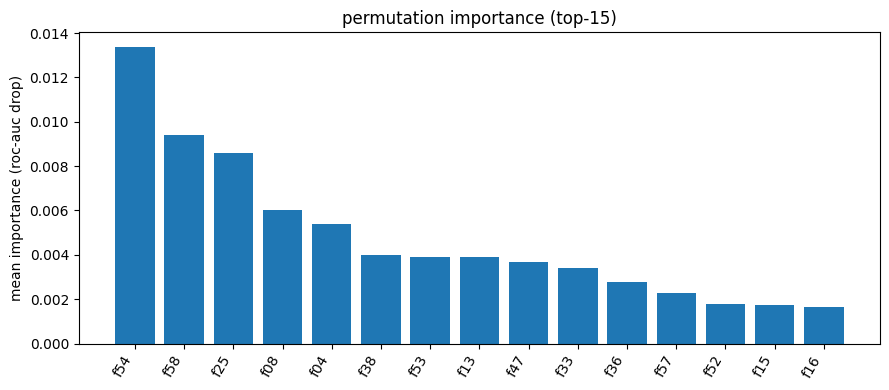

In [137]:
imp = result.importances_mean
idx = np.argsort(imp)[::-1][:15]

feature_names = X.columns

plt.figure(figsize=(9, 4))
plt.bar(range(len(idx)), imp[idx])
plt.xticks(range(len(idx)), [feature_names[i] for i in idx], rotation=60, ha="right")
plt.ylabel(f"mean importance (roc-auc drop)")
plt.title(f"permutation importance (top-15)")
plt.tight_layout()
plt.savefig('artifacts/figures/permutation_importance.png', dpi=100, bbox_inches='tight')
plt.show()

Permutation importance показывает, насколько ухудшается качество модели при случайном перемешивании значений признака. Чем больше ухудшение, тем важнее признак для модели. Собственно мы выделили наиболее важные признаки, однако проанализировать их затруднительно ввиду не интуитивно понятных названий признаков. Далее соберем все артефакты:

In [124]:
def get_model_metrics(model_name, model, y_true, y_pred, y_proba=None):
    
    metrics = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred))
    }
    
    if y_proba is not None:
        try:
            metrics['roc_auc'] = float(roc_auc_score(y_true, y_proba))
        except:
            metrics['roc_auc'] = None
    else:
        metrics['roc_auc'] = None
    
    return metrics

In [125]:
all_models_metrics = {}

dummy_pred = dummy.predict(X_test)
all_models_metrics['DummyClassifier'] = get_model_metrics('DummyClassifier', model, y_test, dummy_pred)

lr_pred = lr_pipeline.predict(X_test)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
all_models_metrics['LogisticRegression'] = get_model_metrics('LogisticRegression', lr_pipeline, y_test, lr_pred, lr_proba)

tree_pred = best_tree.predict(X_test)
tree_proba = best_tree.predict_proba(X_test)[:, 1]
all_models_metrics['DecisionTree'] = get_model_metrics('DecisionTree', best_tree, y_test, tree_pred, tree_proba)

rf_pred = best_forest.predict(X_test)
rf_proba = best_forest.predict_proba(X_test)[:, 1]
all_models_metrics['RandomForest'] = get_model_metrics('RandomForest', best_forest, y_test, rf_pred, rf_proba)

gb_pred = best_gb.predict(X_test)
gb_proba = best_gb.predict_proba(X_test)[:, 1]
all_models_metrics['HistGradientBoosting'] = get_model_metrics('HistGradientBoosting', best_gb, y_test, gb_pred, gb_proba)

ada_pred = best_ada.predict(X_test)
ada_proba = best_ada.predict_proba(X_test)[:, 1]
all_models_metrics['AdaBoost'] = get_model_metrics('AdaBoost', best_ada, y_test, ada_pred, ada_proba)

stacking_pred = stacking.predict(X_test)
stacking_proba = stacking.predict_proba(X_test)[:, 1]
all_models_metrics['Stacking'] = get_model_metrics('Stacking', stacking, y_test, stacking_pred, stacking_proba)

with open('artifacts/metrics_test.json', 'w', encoding='utf-8') as f:
    json.dump(all_models_metrics, f, indent=4, ensure_ascii=False)
print("Сохранены метрики на тесте: artifacts/metrics_test.json")

Сохранены метрики на тесте: artifacts/metrics_test.json


In [126]:
search_summaries = {
    'DecisionTree': {
        'best_params': tree.best_params_,
        'best_score': float(tree.best_score_),
    },
    'RandomForest': {
        'best_params': forest.best_params_,
        'best_score': float(forest.best_score_),
    },
    'HistGradientBoosting': {
        'best_params': gb.best_params_,
        'best_score': float(gb.best_score_),
    },
    'AdaBoost': {
        'best_params': ada.best_params_,
        'best_score': float(ada.best_score_),
    }
}

with open('artifacts/search_summaries.json', 'w', encoding='utf-8') as f:
    json.dump(search_summaries, f, indent=4, ensure_ascii=False)
print("Сохранены параметры моделей: artifacts/search_summaries.json")

Сохранены параметры моделей: artifacts/search_summaries.json


In [128]:
joblib.dump(stacking, 'artifacts/best_model.joblib')
print("Сохранена лучшая модель: artifacts/best_model.joblib")

Сохранена лучшая модель: artifacts/best_model.joblib


In [136]:
stacking_estimators_info = []

if hasattr(stacking, 'estimators_'):
    for i, (name, estimator) in enumerate(stacking.estimators):
        estimator_info = {
            'name': name,
            'estimator_type': type(estimator).__name__
        }
        stacking_estimators_info.append(estimator_info)
else:
    for name, estimator in stacking.estimators:
        estimator_info = {
            'name': name,
            'estimator_type': type(estimator).__name__
        }
        stacking_estimators_info.append(estimator_info)

cv_info = str(stacking.cv)
if hasattr(stacking.cv, 'n_splits'):
    cv_info = f"StratifiedKFold(n_splits={stacking.cv.n_splits})"

best_model_meta = {
    'model_name': 'StackingClassifier',
    'final_estimator': type(stacking.final_estimator_).__name__,
    'base_estimators': stacking_estimators_info,
    'cv_parameter': cv_info,
    'passthrough': stacking.passthrough if hasattr(stacking, 'passthrough') else False,
    'test_metrics': all_models_metrics['Stacking'],
    'permutation_importance': {
        'top_15_features': importance_df.head(15)[['feature', 'importance_mean', 'importance_std']].to_dict('records')
    },
    'experiment_info': {
        'dataset': 'S06-hw-dataset-04.csv',
        'test_size': 0.2,
        'random_state': 42,
        'stratify': True,
        'scoring': 'roc_auc',
        'target_distribution': {
            'class_0': float(data['target'].value_counts(normalize=True)[0]),
            'class_1': float(data['target'].value_counts(normalize=True)[1])
        },
        'best_model_selection_criteria': 'ROC-AUC'
    }
}

with open('artifacts/best_model_meta.json', 'w', encoding='utf-8') as f:
    json.dump(best_model_meta, f, indent=4, ensure_ascii=False)
print("Сохранены метаданные: artifacts/best_model_meta.json")

Сохранены метаданные: artifacts/best_model_meta.json


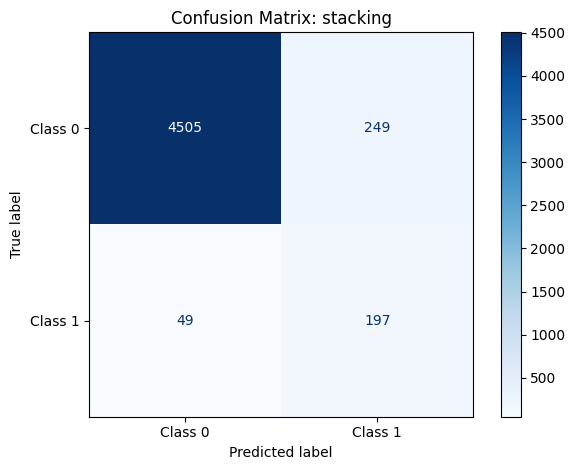

Сохранена confusion matrix: artifacts/figures/confusion_matrix_best.png


In [134]:
cm = confusion_matrix(y_test, stacking_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix: stacking')
plt.tight_layout()
plt.savefig('artifacts/figures/confusion_matrix_best.png', dpi=100, bbox_inches='tight')
plt.show()
print("Сохранена confusion matrix: artifacts/figures/confusion_matrix_best.png")

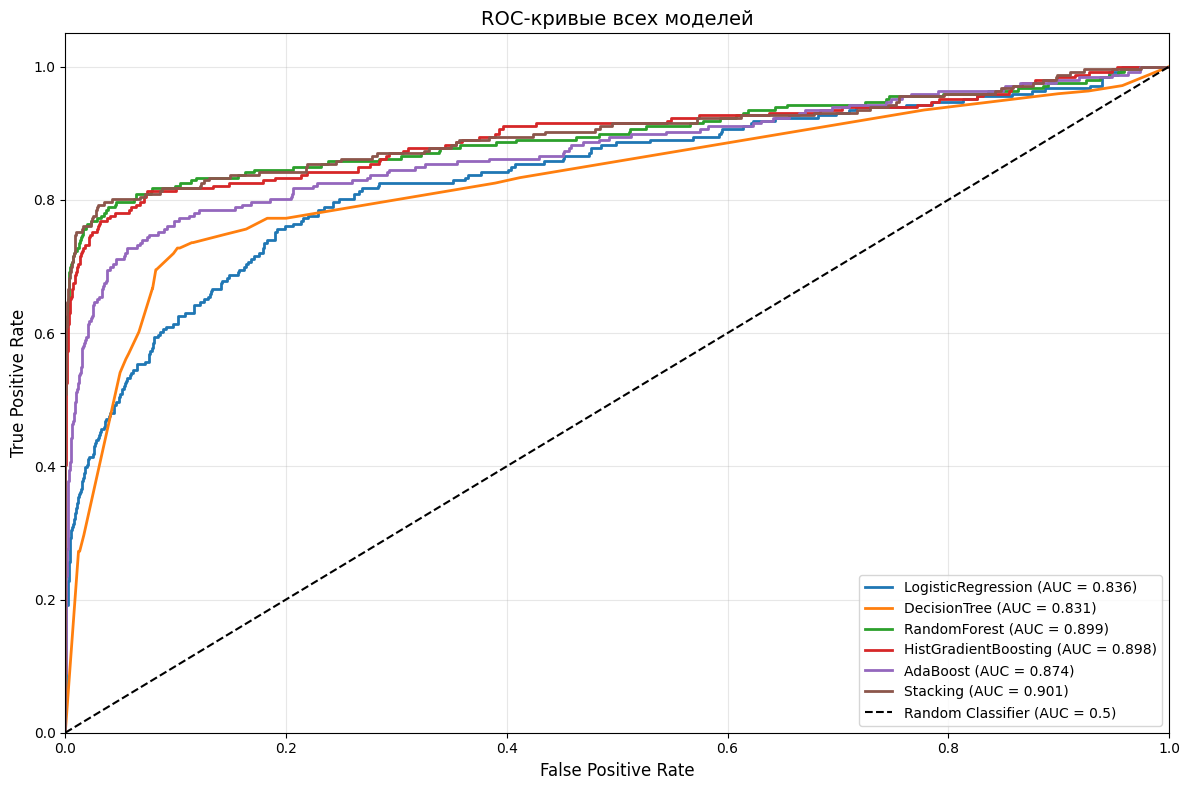

Сохранены ROC-кривые: artifacts/figures/roc_curves_all_models.png


In [127]:
plt.figure(figsize=(12, 8))

models_with_proba = [
    ('LogisticRegression', lr_pipeline, lr_proba),
    ('DecisionTree', best_tree, tree_proba),
    ('RandomForest', best_forest, rf_proba),
    ('HistGradientBoosting', best_gb, gb_proba),
    ('AdaBoost', best_ada, ada_proba),
    ('Stacking', stacking, stacking_proba)
]

for name, model, proba in models_with_proba:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые всех моделей', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig('artifacts/figures/roc_curves_all_models.png', dpi=100, bbox_inches='tight')
plt.show()
print("Сохранены ROC-кривые: artifacts/figures/roc_curves_all_models.png")